# Comparison between Offline Methods

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

list_df = []
for num in [50, 60, 70, 90, 120, 150]:
    scenario_name = f'ev_scenario-{num}'
    pickle_result = f'./offline/metrics_{scenario_name}'
    num = int(scenario_name.split('-')[1])
    dir_scenario = f'./offline/ev_scenario-{num}/'
    
    scenarios_results = []
    with open(f"{pickle_result}.pickle", "rb") as f:
        results = pickle.load(f)

    df_ = pd.DataFrame(columns=list(results[0].keys()))
    for i, res in enumerate(results):
        df_.loc[i] = list(res.values())
    df_['Algorithm'] = df_['filename'].apply(lambda x: x.split('-')[0].upper())
    df_['Scenarios'] = scenario_name
    list_df.append( df_ )

list_df = pd.concat( list_df )
list_df['timeout'] = list_df['timeout'].astype(float)
list_df['GAP_P1'] = list_df['GAP_P1'].astype(float)
list_df['GAP_P2'] = list_df['GAP_P2'].astype(float)
list_df['GAP_P3'] = list_df['GAP_P3'].astype(float)
list_df['reward value'] = list_df['reward value'].astype(float)
list_df['solved'] = list_df['solved'].astype(float)
TO_time = 1800

df_res = list_df.copy()
df_res['Timeout'] = df_res['computation_time'].apply(lambda e: 1. if e >= TO_time else 0.)
df_res['Computation Time'] = df_res['computation_time'].apply(lambda e: TO_time if e >= TO_time else e)
df_res['Scenarios'] = df_res['Scenarios'].replace({**{f'ev_scenario-{num}': f'Scenario {num} EVs' for num in [50, 60, 70, 90, 120, 150]}})
df_res['Algorithm'] = df_res['Algorithm'].replace({'1PHASE_MODEL': '(1P) MILP', '2PHASE_MODEL': '(2P) MILP', '3PHASE_MODEL': '(3P) MILP'})
df_res = df_res[(df_res['Algorithm'] == '(1P) MILP') | (df_res['Algorithm'] == '(2P) MILP') | (df_res['Algorithm'] == '(3P) MILP')]
df_res['num'] = df_res['filename'].apply(lambda e: e.split('-')[-1].split('.')[0])
df_res = df_res[['Scenarios', 'Algorithm', 'Computation Time', 'Timeout', 'GAP_P1', 'GAP_P2', 'GAP_P3', 'solved', 'reward value', 'num']]

default_values = {
    'Computation Time': 1800.0,  # Default computation time
    'Timeout': 1.0,              # Default timeout
    'GAP_P1': 0.,
    'GAP_P2': 0.,
    'GAP_P3': 0.,
    'solved': 0.,
}

expanded_df = pd.DataFrame()
for (scenario, algorithm), group in df_res.groupby(['Scenarios', 'Algorithm']):
    rows_to_add = 100 - len(group)
    if rows_to_add > 0:
        additional_rows = {key: [value] * rows_to_add for key, value in default_values.items()}
        additional_rows['Scenarios'] = [scenario] * rows_to_add
        additional_rows['Algorithm'] = [algorithm] * rows_to_add
        additional_df = pd.DataFrame(additional_rows)
        group = pd.concat([group, additional_df], ignore_index=True)
    
    expanded_df = pd.concat([expanded_df, group], ignore_index=True)

In [21]:
expanded_df.groupby(['Scenarios', 'Algorithm']).agg({
    'Computation Time': ['median', 'mean', 'std'],  # Get median, mean, and std for computation time
    'Timeout': ['sum'],
})

Computation Time                          Timeout
                                     median         mean         std     sum
Scenarios        Algorithm                                                  
Scenario 120 EVs (1P) MILP      1800.000000  1800.000000    0.000000   100.0
                 (2P) MILP      1800.000000  1800.000000    0.000000   100.0
                 (3P) MILP       710.485746   968.469055  688.791655    37.0
Scenario 150 EVs (1P) MILP      1800.000000  1800.000000    0.000000   100.0
                 (2P) MILP      1800.000000  1800.000000    0.000000   100.0
                 (3P) MILP      1800.000000  1609.519839  399.779876    78.0
Scenario 50 EVs  (1P) MILP        22.331753   252.513734  531.245272     8.0
                 (2P) MILP         3.973054    33.730203  183.282863     1.0
                 (3P) MILP         2.391871    20.910272  179.718244     1.0
Scenario 60 EVs  (1P) MILP      1767.917028  1148.771331  756.945352    50.0
                 (2P) MILP        38.077609   215.607022  443.781029     6.0
                 (3P) MILP         7.727075    26.313691  179.221843     1.0
Scenario 70 EVs  (1P) MILP      1800.000000  1612.279690  518.196803    88.0
                 (2P) MILP       333.122382   765.284673  738.882968    30.0
                 (3P) MILP        18.609040    94.799786  350.538301     4.0
Scenario 90 EVs  (1P) MILP      1800.000000  1786.342506  136.574938    99.0
                 (2P) MILP      1800.000000  1752.124038  216.351215    93.0
                 (3P) MILP        73.520562   324.440478  576.448206    11.0

In [15]:
expanded_df[expanded_df['Algorithm'] == '(1P) MILP'].groupby(['Scenarios', 'Algorithm']).agg({
    'GAP_P1': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 1
})

GAP_P1                            
                               median          mean           std
Scenarios        Algorithm                                       
Scenario 120 EVs (1P) MILP   0.216652  2.419737e+12  1.383035e+13
Scenario 150 EVs (1P) MILP  14.353209  1.995567e+13  3.591022e+13
Scenario 50 EVs  (1P) MILP   0.000082  4.791500e-03  1.916163e-02
Scenario 60 EVs  (1P) MILP   0.000730  2.041050e-02  2.589134e-02
Scenario 70 EVs  (1P) MILP   0.063010  6.094689e-02  3.744689e-02
Scenario 90 EVs  (1P) MILP   0.112010  1.175591e-01  6.472928e-02

In [16]:
expanded_df[expanded_df['Algorithm'] == '(2P) MILP'].groupby(['Scenarios', 'Algorithm']).agg({
    'GAP_P1': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 1
    'GAP_P2': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 2
})

GAP_P1                        GAP_P2            \
                             median      mean       std    median      mean   
Scenarios        Algorithm                                                    
Scenario 120 EVs (2P) MILP  0.00000  0.266459  1.501582  0.024245  0.037015   
Scenario 150 EVs (2P) MILP  0.02847  1.770725  4.850737  0.038625  0.231819   
Scenario 50 EVs  (2P) MILP  0.00000  0.000655  0.004778  0.000016  0.000035   
Scenario 60 EVs  (2P) MILP  0.00000  0.000690  0.004852  0.000081  0.012705   
Scenario 70 EVs  (2P) MILP  0.00000  0.000622  0.003712  0.000099  0.008254   
Scenario 90 EVs  (2P) MILP  0.00000  0.003345  0.009884  0.022840  0.026778   

                                      
                                 std  
Scenarios        Algorithm            
Scenario 120 EVs (2P) MILP  0.087020  
Scenario 150 EVs (2P) MILP  0.275561  
Scenario 50 EVs  (2P) MILP  0.000039  
Scenario 60 EVs  (2P) MILP  0.107154  
Scenario 70 EVs  (2P) MILP  0.017360  
Scenario 90 EVs  (2P) MILP  0.023775

In [17]:
expanded_df[expanded_df['Algorithm'] == '(3P) MILP'].groupby(['Scenarios', 'Algorithm']).agg({
    'GAP_P1': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 1
    'GAP_P2': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 2
    'GAP_P3': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP Phase 3
})

GAP_P1                      GAP_P2            \
                              median      mean        std median mean  std   
Scenarios        Algorithm                                                   
Scenario 120 EVs (3P) MILP  0.000000  0.451961   2.169835    0.0  0.0  0.0   
Scenario 150 EVs (3P) MILP  0.028269  3.046447  14.890420    0.0  0.0  0.0   
Scenario 50 EVs  (3P) MILP  0.000000  0.000238   0.002381    0.0  0.0  0.0   
Scenario 60 EVs  (3P) MILP  0.000000  0.000541   0.003950    0.0  0.0  0.0   
Scenario 70 EVs  (3P) MILP  0.000000  0.000942   0.004295    0.0  0.0  0.0   
Scenario 90 EVs  (3P) MILP  0.000000  0.056722   0.538263    0.0  0.0  0.0   

                              GAP_P3                      
                              median      mean       std  
Scenarios        Algorithm                                
Scenario 120 EVs (3P) MILP  0.000012  0.000027  0.000032  
Scenario 150 EVs (3P) MILP  0.000013  0.001393  0.013665  
Scenario 50 EVs  (3P) MILP  0.000013  0.000023  0.000029  
Scenario 60 EVs  (3P) MILP  0.000008  0.000026  0.000032  
Scenario 70 EVs  (3P) MILP  0.000012  0.000028  0.000031  
Scenario 90 EVs  (3P) MILP  0.000005  0.000024  0.000030

In [24]:
expanded_df['Relative Reward Difference (RRD)'] = float('nan')
expanded_df['RRD comparison size'] = 0.
for scenario in [50, 60, 70, 90, 120, 150]:
    for algo in ['(1P) MILP', '(2P) MILP', '(3P) MILP']:
        condition = (expanded_df['Algorithm'] == algo) & \
                    (expanded_df['solved'] == 1.) & \
                    (expanded_df['Scenarios'] == f'Scenario {scenario} EVs')
        df_algo = expanded_df[condition]
        df_ref = expanded_df[(expanded_df['Algorithm'] == '(1P) MILP') & 
                             (expanded_df['solved'] == 1.) & 
                             (expanded_df['Scenarios'] == f'Scenario {scenario} EVs')]
        df_merge = pd.merge(df_algo, df_ref, on='num', suffixes=(' - algo', ' - ref'))
        df_merge['Relative Reward Difference (RRD)'] = (df_merge['reward value - ref'] - df_merge['reward value - algo']) / df_merge['reward value - ref']
        
        for index, row in df_merge.iterrows():
            match_index = expanded_df[(expanded_df['num'] == row['num']) & (expanded_df['Algorithm'] == algo) & 
                                      (expanded_df['solved'] == 1) & (expanded_df['Scenarios'] == f'Scenario {scenario} EVs')].index
            if not match_index.empty:
                expanded_df.at[match_index[0], 'Relative Reward Difference (RRD)'] = row['Relative Reward Difference (RRD)']
                expanded_df.at[match_index[0], 'RRD comparison size'] += 1

expanded_df.groupby(['Scenarios', 'Algorithm']).agg({
    'reward value': ['median', 'mean', 'std'],  # Get mean and std for Computation Time
    'Relative Reward Difference (RRD)': ['median', 'mean', 'std'],
    'RRD comparison size': 'sum'
})

reward value                            \
                                 median         mean          std   
Scenarios        Algorithm                                          
Scenario 120 EVs (1P) MILP  6572.189729  5614.779871  2473.469878   
                 (2P) MILP  6985.535343  6766.442770  1342.304648   
                 (3P) MILP  6344.938395  6090.749821  1209.154686   
Scenario 150 EVs (1P) MILP   558.877623  2292.789918  3033.581479   
                 (2P) MILP  5764.710429  4062.997536  3179.229388   
                 (3P) MILP  6411.915040  5768.183678  1995.054144   
Scenario 50 EVs  (1P) MILP  4928.403259  4888.188938   304.321158   
                 (2P) MILP  4865.880143  4811.422408   337.165462   
                 (3P) MILP  4763.810484  4732.494399   410.968195   
Scenario 60 EVs  (1P) MILP  5551.295219  5517.561060   321.001879   
                 (2P) MILP  5398.860680  5421.598193   324.379393   
                 (3P) MILP  5200.477433  5182.431637   422.883887   
Scenario 70 EVs  (1P) MILP  5911.543257  5926.743633   402.451055   
                 (2P) MILP  5854.813875  5856.732383   419.914615   
                 (3P) MILP  5438.872975  5426.014676   527.894656   
Scenario 90 EVs  (1P) MILP  6393.725527  6420.338895   498.102819   
                 (2P) MILP  6437.231140  6450.341305   445.618842   
                 (3P) MILP  5792.441701  5759.616246   724.329498   

                           Relative Reward Difference (RRD)            \
                                                     median      mean   
Scenarios        Algorithm                                              
Scenario 120 EVs (1P) MILP                              NaN       NaN   
                 (2P) MILP                              NaN       NaN   
                 (3P) MILP                              NaN       NaN   
Scenario 150 EVs (1P) MILP                              NaN       NaN   
                 (2P) MILP                              NaN       NaN   
                 (3P) MILP                              NaN       NaN   
Scenario 50 EVs  (1P) MILP                         0.000000  0.000000   
                 (2P) MILP                         0.016306  0.016282   
                 (3P) MILP                         0.018601  0.032333   
Scenario 60 EVs  (1P) MILP                         0.000000  0.000000   
                 (2P) MILP                         0.014773  0.016411   
                 (3P) MILP                         0.061357  0.061299   
Scenario 70 EVs  (1P) MILP                         0.000000  0.000000   
                 (2P) MILP                         0.000023  0.009154   
                 (3P) MILP                         0.070597  0.073243   
Scenario 90 EVs  (1P) MILP                         0.000000  0.000000   
                 (2P) MILP                         0.016281  0.016281   
                 (3P) MILP                         0.198142  0.198142   

                                     RRD comparison size  
                                 std                 sum  
Scenarios        Algorithm                                
Scenario 120 EVs (1P) MILP       NaN                 0.0  
                 (2P) MILP       NaN                 0.0  
                 (3P) MILP       NaN                 0.0  
Scenario 150 EVs (1P) MILP       NaN                 0.0  
                 (2P) MILP       NaN                 0.0  
                 (3P) MILP       NaN                 0.0  
Scenario 50 EVs  (1P) MILP  0.000000                92.0  
                 (2P) MILP  0.020502                92.0  
                 (3P) MILP  0.037453                92.0  
Scenario 60 EVs  (1P) MILP  0.000000                50.0  
                 (2P) MILP  0.017831                50.0  
                 (3P) MILP  0.033627                50.0  
Scenario 70 EVs  (1P) MILP  0.000000                12.0  
                 (2P) MILP  0.012459                12.0  
                 (3P) MILP  0.031210    

# General Comparative Results

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def charging_acceptance_analysis(data, selected_scenarios, bar_width=.2,
                                 space_between_groups=-.4, figsize=(20, 8)):
    grouped = data.copy().reset_index()
    grouped['scenario_number'] = grouped['Scenario'].str.extract('(\d+)').astype(int)
    sorted_grouped = grouped.sort_values(by='scenario_number')
    sorted_algorithms = ['(1P) MILP', '(2P) MILP', '(3P) MILP', 'Baseline', 'PS2C', 'MPPO', 'Rolling']
    num_scenarios = len(selected_scenarios)
    num_algorithms = len(sorted_algorithms)

    fig, ax = plt.subplots(figsize=figsize)
    group_width = num_algorithms * bar_width + (num_algorithms - 1) * bar_width
    bar_positions = []
    algorithm_labels = []
    for i, scenario in enumerate(selected_scenarios):
        scenario_position = i * (group_width + space_between_groups)
        for j, algorithm in enumerate(sorted_algorithms):
            algorithm_position = scenario_position + j * bar_width
            bar_positions.append(algorithm_position)
            algorithm_labels.append(algorithm)
            subset = sorted_grouped[(sorted_grouped['Scenario'] == scenario) & (sorted_grouped['Algorithm'] == algorithm)]
            ax.bar(algorithm_position, subset['Charging satisf. >=80%'].apply(lambda e: float(str(e).split('±')[0])), bar_width, yerr=subset['Charging satisf. >=80%'].apply(lambda e: float(str(e).split('±')[1][:-1])), error_kw=dict(ecolor='black', lw=1, capsize=3, capthick=1), label=r'$SoC^f \geq$ 80%' if i == 0 and j == 0 else "", edgecolor='white', color='#0D91A8')
            ax.bar(algorithm_position, subset['Charging satisf. <80%'].apply(lambda e: float(str(e).split('±')[0])), bar_width, yerr=subset['Charging satisf. <80%'].apply(lambda e: float(str(e).split('±')[1][:-1])), error_kw=dict(ecolor='white', lw=1, capsize=3, capthick=1), bottom=subset['Charging satisf. >=80%'].apply(lambda e: float(str(e).split('±')[0])), label=r'$SoC^f <$ 80%' if i == 0 and j == 0 else "", edgecolor='white', color='#0DA88D')
            ax.bar(algorithm_position, subset['Overall charging unsatisf.'].apply(lambda e: float(str(e).split('±')[0])), bar_width, yerr=subset['Overall charging unsatisf.'].apply(lambda e: float(str(e).split('±')[1][:-1])), error_kw=dict(ecolor='black', lw=1, capsize=3, capthick=1), bottom=subset['Charging satisf. <80%'].apply(lambda e: float(str(e).split('±')[0])) + subset['Charging satisf. >=80%'].apply(lambda e: float(str(e).split('±')[0])), label='Rejections' if i == 0 and j == 0 else "", edgecolor='white', color='#C41E3A')
    scenario_positions = [i * (group_width + space_between_groups) + group_width / 3. for i in range(num_scenarios)]
    ax.set_xticks(scenario_positions)
    ax.set_xticklabels(selected_scenarios, verticalalignment='top', horizontalalignment='right', weight='bold', fontsize=13)#, rotation=45)
    ax.set_xticks(bar_positions, minor=True)
    ax.set_xticklabels(algorithm_labels, minor=True, rotation=30, verticalalignment='top', horizontalalignment='right', fontsize=12)
    
    ax.tick_params(axis='x', which='major', pad=70, rotation=0, length=0)
    ax.set_xlabel('Scenarios and Algorithms', fontsize=16, labelpad=15)
    ax.set_ylabel('Repartition (in %)', fontsize=16)
    legend = ax.legend(title='Charging Satisfaction', fontsize='large', title_fontsize='x-large', alignment='left', bbox_to_anchor=(1,1))
    ax.set_ylim(0., 110.)
    ax.grid(True, linestyle='-', linewidth=.5, axis='y')
    # plt.savefig('dist_satif.png', dpi=600, bbox_inches='tight')
    plt.show()


def global_cost_distribution(data, selected_scenarios, bar_width=.6, space_between_groups=.1,
                             figsize=(20, 10), scenario_pad=70):
    def manually_parse_rewards(reward_string):
        try:
            rewards = reward_string.strip('[]').split()
            return [float(reward) for reward in rewards]
        except:
            return []

    data['Parsed Detailed Rewards'] = data['Detailed obj. cost'].apply(manually_parse_rewards)
    expanded_data = pd.DataFrame(columns=['Scenario', 'Algorithm', 'Cost'])
    for index, row in data.iterrows():
        for reward in row['Parsed Detailed Rewards']:
            expanded_data = expanded_data.append({
                'Scenario': row['Scenario'],
                'Algorithm': row['Algorithm'],
                'Reward': reward
            }, ignore_index=True)
    
    unique_algorithms = ['(1P) MILP', '(2P) MILP', '(3P) MILP', 'Baseline', 'PS2C', 'MPPO', 'Rolling']
    colors = ['darkred', 'darkgray', 'darkblue', 'darkviolet', 'darkorange', 'darkcyan', 'darkgreen']
    color_map = dict(zip(unique_algorithms, colors))
    fig, ax = plt.subplots(figsize=figsize)
    group_width = len(unique_algorithms) * bar_width + (len(unique_algorithms) - 1) * bar_width
    
    bar_positions = []
    scenario_positions = [i * (group_width + space_between_groups) + group_width / 3 for i in range(len(selected_scenarios))]
    algorithm_labels = []
    
    for i, scenario in enumerate(selected_scenarios):
        scenario_position = i * (group_width + space_between_groups)
        for j, algorithm in enumerate(unique_algorithms):
            algorithm_position = scenario_position + j * bar_width
            bar_positions.append(algorithm_position)
            rewards = expanded_data[(expanded_data['Scenario'] == scenario) & (expanded_data['Algorithm'] == algorithm)]['Reward']
            if not rewards.empty:
                parts = ax.violinplot(rewards, positions=[algorithm_position], showextrema=True, showmedians=True)
                for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
                    vp = parts[partname]
                    vp.set_edgecolor('black')
                for i, pc in enumerate(parts['bodies']):
                    pc.set_facecolor(color_map[algorithm])
                    pc.set_edgecolor('black')
                    pc.set_alpha(0.75)
                parts['cbars'].set_linewidth(0.5)
                parts['cmedians'].set_edgecolor('white')
                parts['cmedians'].set_linewidth(1.5)
            algorithm_labels.append(algorithm)

    ax.set_xticks(scenario_positions)
    ax.set_xticklabels(selected_scenarios, verticalalignment='top', horizontalalignment='right', weight='bold', fontsize=13)
    ax.set_xticks(bar_positions, minor=True)
    ax.set_xticklabels(algorithm_labels, minor=True, rotation=30, verticalalignment='top', horizontalalignment='right', fontsize=12)
    ax.tick_params(axis='x', which='major', pad=scenario_pad, rotation=0, length=0)  # Add space between major ticks (scenarios) and their labels
    ax.set_xlabel('Scenarios and Algorithms', fontsize=16, labelpad=20)
    ax.set_ylabel('Reward', fontsize=16)
    ax.grid(True, linestyle='-', linewidth=.5, axis='y')
    # plt.savefig('dist_obj.png', dpi=600, bbox_inches='tight')
    plt.show()


In [8]:
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
directory_with_name_list = [('offline', 'offline'),
                            ('rule_based', 'rbc'),
                            ('rolling', 'rolling'),
                            ('reinforcement_learning', 'CustomMPPO')]
columns_selected = ['Algorithm', 'Obj. cost', 'Charging satisf. <80%', 'Charging satisf. >=80%', 'Overall charging satisf.', 'Price', 'Total Energy', 'RES used', 'Energy/EV', 'scenario_name']
scenario_name_dic = {
    50:  'scenario-50',
    60:  'scenario-60',
    70:  'scenario-70',
    90:  'scenario-90',
    120: 'scenario-120',
    150: 'scenario-150',
}

list_df = []
for (dir_name, method_name) in directory_with_name_list:
    for scn_num in scenario_name_dic:
        list_df.append( pd.read_csv(f"./{dir_name}/analysis_{method_name}_{scn_num}.csv",
                                    sep='\t') )
        if(method_name == 'CustomMPPO'):
            list_df[-1] = list_df[-1].loc[(list_df[-1]['Algorithm'] == 'MPPO_eval')]
        
        list_df[-1]['Scenario'] = scenario_name_dic[scn_num]
        list_df[-1]['Scenario'] = list_df[-1]['Scenario'].replace({**{f'scenario-{num}': f'Scenario {num} EVs' for num in [50, 60, 70, 90, 120, 150]}})
        list_df[-1]['Algorithm'] = list_df[-1]['Algorithm'].replace({'BASELINE': 'Baseline', 'PS2C': 'PS2C', 'MPPO_eval': 'MPPO', '1PHASE_MODEL': '(1P) MILP', '2PHASE_MODEL': '(2P) MILP', '3PHASE_MODEL': '(3P) MILP', 'ROLLING': 'Rolling'})

df = pd.concat( list_df )
df.sort_values(by=['Scenario', 'Algorithm'])#[['Scenario', 'Algorithm', 'Charging satisf. >=80%', 'Overall charging satisf.', 'Price', 'Grid limit', 'PV used', 'Obj. cost']]

,Algorithm,Charging satisf. <80%,Charging satisf. >=80%,Overall charging satisf.,Overall charging unsatisf.,Charging auto rejection,Price,Grid limit,Total Energy,Total PV,PV used,Grid used,PV used/Total PV,PV used/Total Energy,Energy/EV,SoC charged,Final SoC,Waiting Time,Obj. cost,Detailed obj. cost,Detailed PV used,Detailed Total Energy,Detailed Total PV,Scenario
0,(1P) MILP,9.21±5.25%,42.13±18.53%,51.34±22.22%,48.65±22.21%,4.48±3.56%,57.32±29.42,0,943.52±401.66,284.89±127.98,238.29±149.23,705.23±318.08,83.16±33.36%,24.68±13.40%,15.12±3.35,30.57±6.77%,72.63±13.52%,4.73±1.91,5614.78±2461.07,[6477.219372 6758.29633338 7589.633959 658...,[418.94372 374.71333375 453.08959 437.17...,[1146.75 1091.75 1256.75 1119.25 41.25 1086....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
1,(2P) MILP,9.08±4.36%,50.96±10.14%,60.03±11.75%,39.96±11.76%,4.58±2.75%,68.96±20.99,0,1124.37±215.01,284.89±127.98,274.44±132.20,849.92±201.91,95.82±17.26%,24.33±11.74%,15.71±1.67,31.77±3.37%,76.25±3.48%,5.32±1.18,6766.44±1335.58,[7167.044372 6561.77597375 7658.258959 797...,[418.94372 379.2597375 453.08959 437.17...,[1248.5 1061.5 1270.5 1300.75 1232. 1141....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
2,(3P) MILP,15.14±4.36%,45.24±9.05%,60.38±11.41%,39.61±11.42%,7.58±3.82%,62.85±19.86,0,1051.27±196.84,284.89±127.98,274.06±132.68,777.21±191.37,95.77±17.11%,25.68±11.94%,14.66±1.31,29.64±2.65%,72.31±2.57%,5.60±1.11,6090.75±1203.09,[6160.24100419 6471.50738875 6475.308959 650...,[418.91004187 371.0738875 453.08959 437.17...,[1116.5 1056. 1100. 1116.5 1122. 1108....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
1,Baseline,25.84±4.53%,30.00±4.18%,55.84±4.30%,44.15±4.31%,31.57±4.31%,87.16±16.43,0,1326.19±96.37,284.89±127.98,281.85±125.68,1044.34±107.48,99.18±2.09%,20.97±9.10%,19.85±1.47,40.14±2.97%,79.26±2.55%,8.00±0.76,4182.94±525.13,[5165.88250184 3955.02056609 4780.95181356 477...,[418.94372 363.24255409 448.10892743 437.17...,[1460.11870156 1213.03689322 1438.59079181 145...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
1,MPPO,14.68±3.71%,36.18±3.01%,50.87±3.76%,49.12±3.76%,1.42±2.38%,77.53±15.36,0,1224.93±68.39,284.89±127.98,281.75±125.50,943.18±116.93,99.17±1.80%,22.85±10.01%,20.13±1.22,40.70±2.46%,85.19±1.90%,3.33±0.45,4874.87±381.19,[5402.34496002 4922.81306261 5075.74371426 554...,[418.51830625 394.12526732 451.363395 433.72...,[1295.06870605 1165.99464123 1293.92625238 129...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
0,PS2C,21.07±3.63%,34.77±3.51%,55.84±4.30%,44.15±4.31%,31.57±4.31%,74.10±16.37,0,1184.63±67.87,284.89±127.98,278.72±123.77,905.91±124.63,98.27±2.24%,23.45±10.39%,17.74±1.13,35.87±2.28%,74.99±1.54%,8.00±0.76,4769.00±450.70,[5288.2873595 4366.08081775 5196.91182431 499...,[414.873595 379.83351756 435.74421201 437.17...,[1232. 1119.02534006 1266.62596889 125...,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
0,Rolling,19.12±3.32%,35.88±3.25%,55.00±4.25%,44.99±4.26%,31.06±4.44%,58.97±15.97,0,1012.69±71.27,284.89±127.98,272.37±120.89,740.31±130.69,96.31±5.21%,26.92±12.05%,15.40±1.22,31.14±2.46%,70.18±2.22%,8.01±0.77,4907.03±419.33,[5666.944372 4783.0417735 5202.79956181 501...,[418.94372 368.167735 425.24561812 405.31...,[1149.5 937.75 1097.25 1045. 907.5 995....,[418.94372 424.96714 453.08959 437.17869 430.0...,Scenario 120 EVs
0,(1P) MILP,4.25±5.94%,13.65±17.98%,17.90±23.52%,82.09±23.51%,2.60±4.39%,22.71±30.29,0,383.87±494.55,284.70±123.23,103.40±144.84,280.47±360.09,32.75±43.24%,19.97±21.99%,11.08±7.25,22.41±14.67%,54.69±32.05%,2.38±2.35,2292.79±3018.38,[ 9.8625 7041.683298 542.3761135 48...,[ 0. 326.83298 14.511135 7.82...,[ 2.75 1210. 90.75 101.75 115.5 1097....,[397.36306 326.83298 63.85315 383.49007 194.5...,Scenario 150 EVs
1,(2P) MILP,5.53±5.45%,24.36±18.97%,29.89±23.46%,70.09±23.48%,4.20±4.55%,39.40±33.02,0,668.33±506.46,284.70±123.23,173.68±148.52,494.65±393.96,60.70±42.02%,27.95±21.00%,14.99±4.35,30.32±8.7

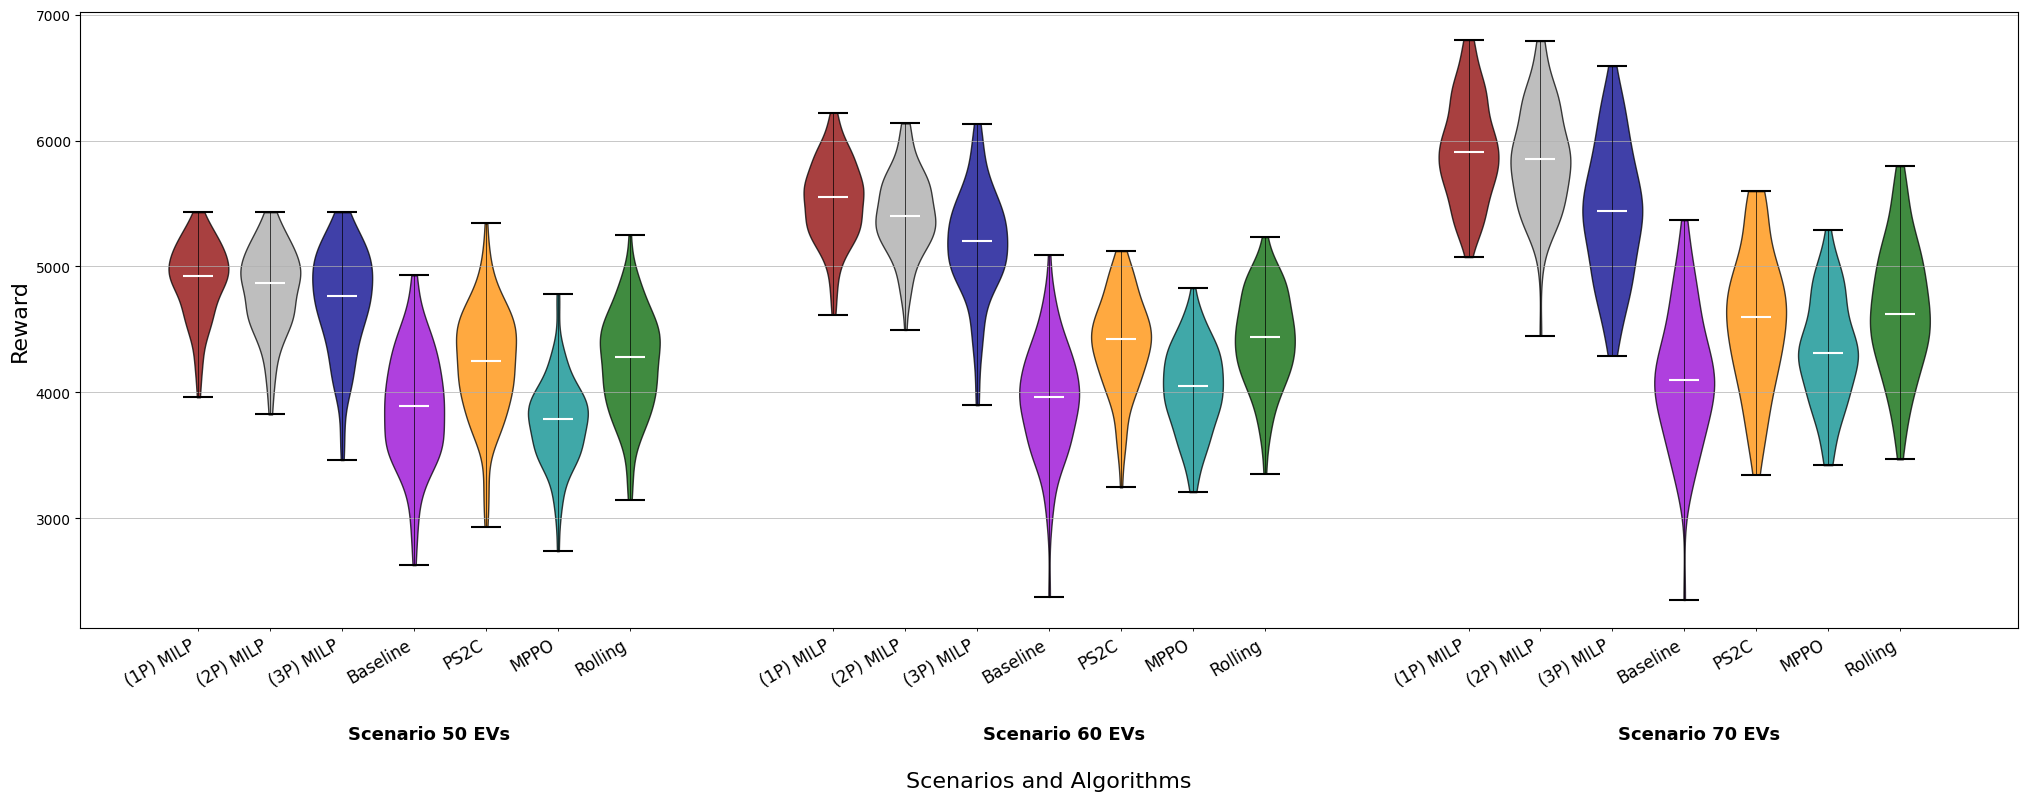

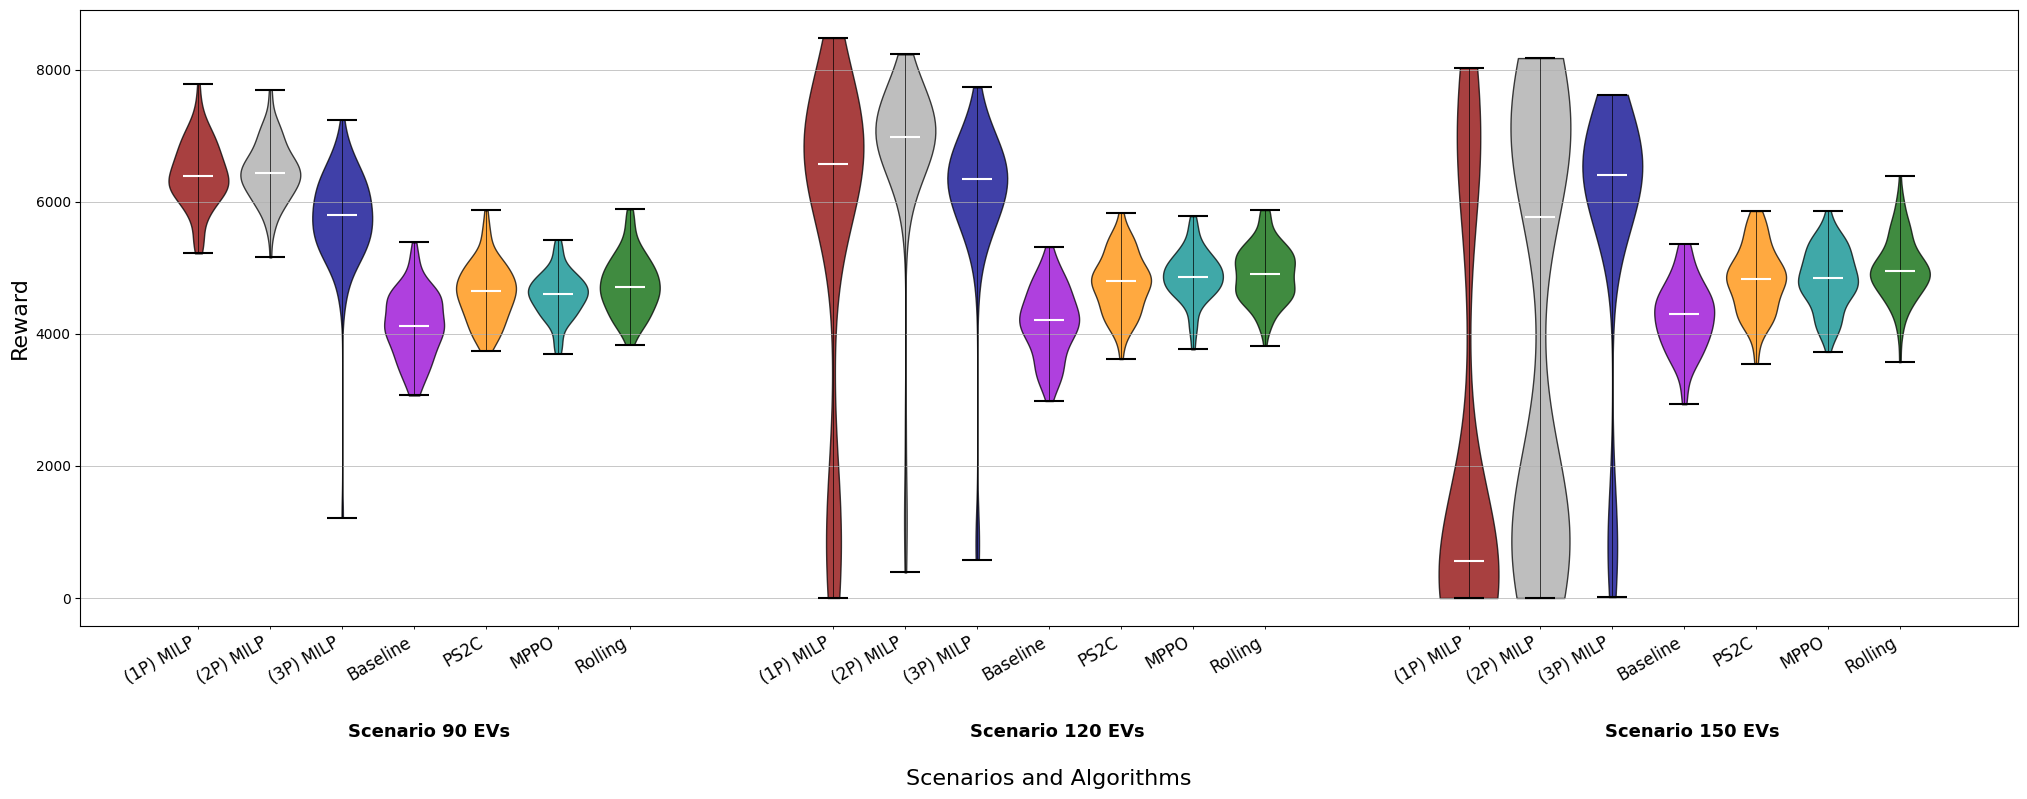

In [9]:
global_cost_distribution(df, selected_scenarios=['Scenario 50 EVs', 'Scenario 60 EVs', 'Scenario 70 EVs'],
                         bar_width=.6, space_between_groups=-2.5, figsize=(25, 8))

global_cost_distribution(df, selected_scenarios=['Scenario 90 EVs', 'Scenario 120 EVs', 'Scenario 150 EVs'],
                         bar_width=.6, space_between_groups=-2.5, figsize=(25, 8))

In [10]:
class ComputeRatioPerc:
    def __init__(self, column_name_1, column_name_2):
        self.column_name_1 = column_name_1
        self.column_name_2 = column_name_2
    
    def __call__(self, row):
        m1, s1 = map(float, row[self.column_name_1].split('±'))
        m2, s2 = map(float, row[self.column_name_2].split('±'))
        rm = m1/m2
        rs = (rm * np.sqrt((s1 / m1) ** 2 + (s2 / m2) ** 2))
        return f"{rm*100:.2f}±{rs*100:.2f}%"


cumulative_grid_limit = 75 * 24
df['Grid used/Grid limit'] = df['Grid used'].apply(lambda e: f"{float(e.split('±')[0])/cumulative_grid_limit*100:.2f}±{float(e.split('±')[1])/cumulative_grid_limit*100:.2f}%")
df['PV used/Total energy'] = df.apply(ComputeRatioPerc('PV used', 'Total Energy'), axis=1)
df['PV used/Total PV'] = df.apply(ComputeRatioPerc('PV used', 'Total PV'), axis=1)
df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Price', 'Grid used/Grid limit', 'PV used/Total energy', 'PV used/Total PV']]

,Scenario,Algorithm,Price,Grid used/Grid limit,PV used/Total energy,PV used/Total PV
0,Scenario 120 EVs,(1P) MILP,57.32±29.42,39.18±17.67%,25.26±19.12%,83.64±64.46%
1,Scenario 120 EVs,(2P) MILP,68.96±20.99,47.22±11.22%,24.41±12.65%,96.33±63.45%
2,Scenario 120 EVs,(3P) MILP,62.85±19.86,43.18±10.63%,26.07±13.53%,96.20±63.53%
3,Scenario 120 EVs,Baseline,87.16±16.43,58.02±5.97%,21.25±9.60%,98.93±62.62%
4,Scenario 120 EVs,MPPO,77.53±15.36,52.40±6.50%,23.00±10.33%,98.90±62.57%
5,Scenario 120 EVs,PS2C,74.10±16.37,50.33±6.92%,23.53±10.53%,97.83±61.80%
6,Scenario 120 EVs,Rolling,58.97±15.97,41.13±7.26%,26.90±12.09%,95.61±60.38%
7,Scenario 150 EVs,(1P) MILP,22.71±30.29,15.58±20.00%,26.94±51.26%,36.32±53.25%
8,Scenario 150 EVs,(2P) MILP,39.40±33.02,27.48±21.89%,25.99±29.69%,61.00±58.47%
9,Scenario 150 EVs,(3P) MILP,59.22±24.62,40.44±15.10%,25.85±16.86%,89.16±62.98%


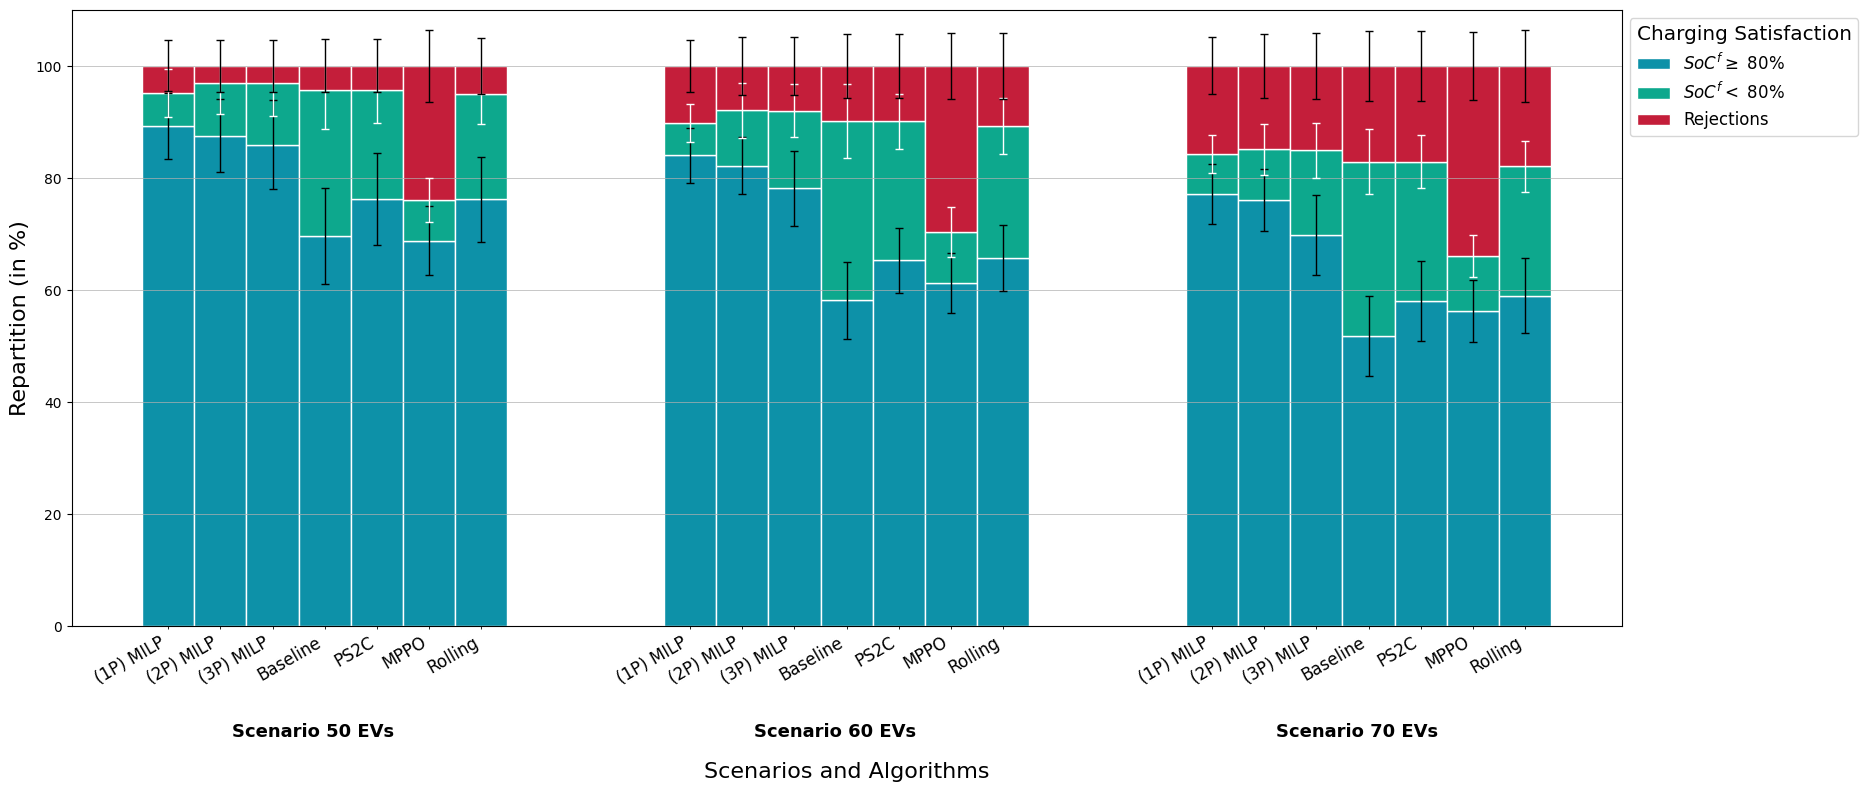

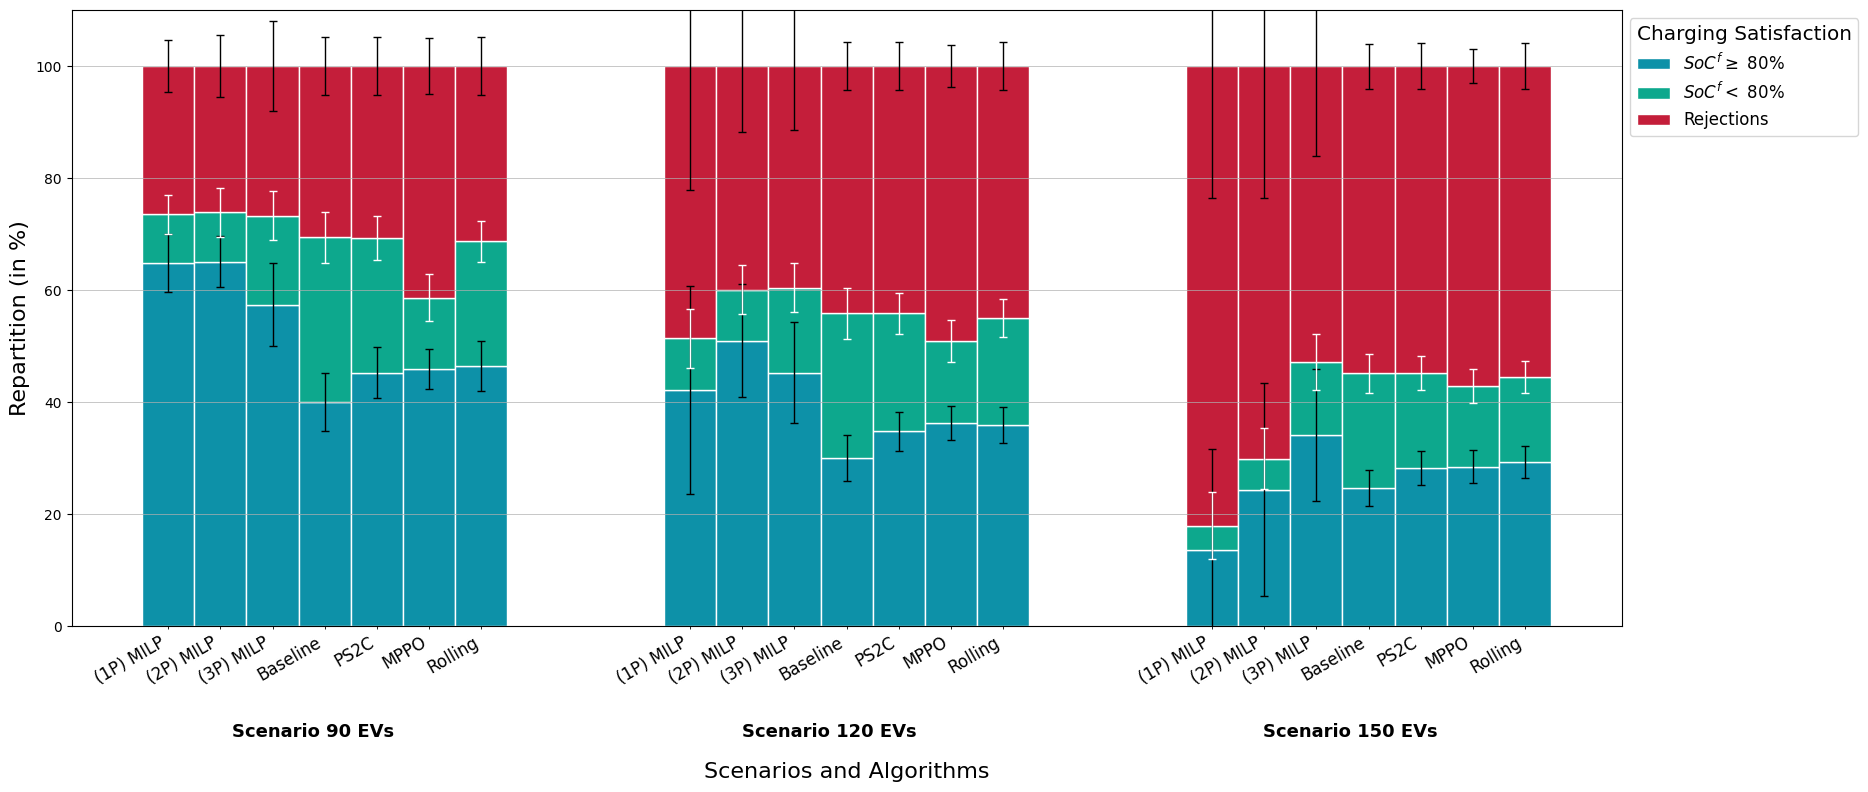

In [11]:
charging_acceptance_analysis(df, selected_scenarios=['Scenario 50 EVs', 'Scenario 60 EVs', 'Scenario 70 EVs'],
                             bar_width=.25, space_between_groups=-.75, figsize=(20, 8))

charging_acceptance_analysis(df, selected_scenarios=['Scenario 90 EVs', 'Scenario 120 EVs', 'Scenario 150 EVs'],
                             bar_width=.25, space_between_groups=-.75, figsize=(20, 8))

In [13]:
df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Overall charging satisf.', 'Waiting Time', 'SoC charged', 'Final SoC']]

,Scenario,Algorithm,Overall charging satisf.,Waiting Time,SoC charged,Final SoC
0,Scenario 120 EVs,(1P) MILP,51.34±22.22%,4.73±1.91,30.57±6.77%,72.63±13.52%
1,Scenario 120 EVs,(2P) MILP,60.03±11.75%,5.32±1.18,31.77±3.37%,76.25±3.48%
2,Scenario 120 EVs,(3P) MILP,60.38±11.41%,5.60±1.11,29.64±2.65%,72.31±2.57%
3,Scenario 120 EVs,Baseline,55.84±4.30%,8.00±0.76,40.14±2.97%,79.26±2.55%
4,Scenario 120 EVs,MPPO,50.87±3.76%,3.33±0.45,40.70±2.46%,85.19±1.90%
5,Scenario 120 EVs,PS2C,55.84±4.30%,8.00±0.76,35.87±2.28%,74.99±1.54%
6,Scenario 120 EVs,Rolling,55.00±4.25%,8.01±0.77,31.14±2.46%,70.18±2.22%
7,Scenario 150 EVs,(1P) MILP,17.90±23.52%,2.38±2.35,22.41±14.67%,54.69±32.05%
8,Scenario 150 EVs,(2P) MILP,29.89±23.46%,3.71±2.15,30.32±8.79%,72.00±17.56%
9,Scenario 150 EVs,(3P) MILP,47.16±16.03%,5.14±1.46,28.14±3.66%,71.11±3.72%
